# Zero-Lag EMA — a quantitative teardown 🔬
### Causal ZLEMA on 5 indices · `price > ZLEMA` forward returns · one-sample HAC *t* · a drift-matched random-entry baseline · a **plain-EMA head-to-head** · a de-lag placebo · the whippy-upcross foil · costs · a synthetic planted-trend control

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Removing_lag_buys_edge%3F: Busted](https://img.shields.io/badge/Removing_lag_buys_edge%3F-Busted-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). Two jobs: separate the **filter** from the **drift** (an upward-trending index makes *any* long-in-uptrend rule look good), and separate the **de-lag** from the **plain EMA** (the one thing ZLEMA is supposed to improve on).

> ⚠️ **Data note.** 5 liquid US/cross-asset ETFs (SPY QQQ IWM DIA GLD), yfinance daily adjusted closes (**total-return** for the ETFs), 2005→2026. ZLEMA is causal (length 20, lag 9); entry is the **next close** (one documented lag). Offline core + synthetic control are deterministic. Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md).
>
> 💡 **The `💡 In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from zlema import data, strategy as st

ASOF = "2026-05-31"
HAVE_REAL = data.have_real()
def load(t):
    b = data.load_real(t, allow_fetch=False)
    return b[b.index <= ASOF]
print("real ZLEMA cache present:", HAVE_REAL, "| tickers:", data.DEFAULT_TICKERS)

# frozen headline numbers (mirror of docs/results.md)
R = {'asof': '2026-05-31', 'start': '2005-01-03', 'end': '2026-05-29', 'years': 21.4, 'tickers': ['SPY', 'QQQ', 'IWM', 'DIA', 'GLD'], 'n_entries': 2811, 'length': 20, 'step': 5, 'fp_spy': '4cb5244f3990', 'h5': (5, 2806, 15.1, 56, 3.58, 24.7, -9.6, 19.4, -4.2, 13.1, -1.37, 0.17), 'h10': (10, 2806, 44.8, 62, 6.53, 54.3, -9.5, 43.9, 0.9, 42.8, -0.99, 0.323), 'h20': (20, 2799, 96.0, 64, 8.09, 117.2, -21.2, 80.6, 15.4, 94.0, -1.57, 0.116), 'h60': (60, 2779, 265.0, 68, 7.93, 279.5, -14.6, 250.7, 14.2, 263.0, -0.63, 0.529), 'per': [('SPY', 566, 88.0, 3.82, 115.6, -27.5, 7.3), ('QQQ', 568, 122.1, 4.1, 171.8, -49.7, 4.0), ('IWM', 554, 90.4, 2.94, 106.2, -15.8, 39.3), ('DIA', 558, 80.8, 3.66, 104.3, -23.6, 18.6), ('GLD', 565, 98.4, 3.57, 87.5, 11.0, 7.7)], 'placebo': (88.0, 0.363, 500), 'upcross': (602, 72.6, 68, 2.48), 'syn': [(0.0, 403, 0.3, 47, 0.01, 18.3, 0.55), (2.0, 565, 5676.8, 62, 4.94, 9589.1, 7.52)]}


real ZLEMA cache present: True | tickers: ['SPY', 'QQQ', 'IWM', 'DIA', 'GLD']


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | `price>ZLEMA` vs a **drift-matched random** baseline: the filter is *worse* at all horizons (Δ = -10/-10/-21/-15 bps) and the Welch *t* is **negative everywhere** (20d = -1.57). |
| **Tradability** | `MIRAGE` | The big one-sample t's (20d = 8.09) are **pure beta** — they vanish against random entries and against cost. No residual edge to scale. |
| **Removing lag buys edge?** | `BUSTED` | Head-to-head vs a plain EMA: ZLEMA − EMA = -4/+1/+15/+14 bps (tiny, sign-flipping); de-lag placebo **p = 0.36**. |

> 💡 In plain words: the filter *looks* significant only because indices drift up. Strip the drift (race vs random) or strip the de-lag (vs plain EMA, or scramble the offset) and the edge evaporates. Classic beta-in-a-costume, with a cosmetic de-lag.

## 1 · The claim, steelmanned

A plain EMA $E_t = \alpha C_t + (1-\alpha)E_{t-1}$ lags price by $\approx (L-1)/2$ bars. Ehlers' fix feeds the EMA a **de-lagged** input: with $\text{lag}=(L-1)/2$,

$$Z_t = \mathrm{EMA}_L\!\big(C_t + (C_t - C_{t-\text{lag}})\big).$$

The $(C_t - C_{t-\text{lag}})$ term is the momentum over the lag window; adding it back pushes the input forward. The rule: **long while $C_t > Z_t$.**

- **H₀ (drift).** Filter returns equal a drift-matched **random-entry** baseline.
- **H₁ (the filter forecasts).** Filter returns **exceed** random at some horizon, t ≥ 2.
- **H₂ (the de-lag matters).** Filter returns **exceed** the **plain-EMA** filter (and a **shuffled-offset** placebo).

We find **H₀ not rejected** (filter < random at every horizon), **H₁ rejected** (Welch t negative throughout), **H₂ rejected** (ZLEMA ≈ EMA; placebo p ≈ 0.36). All three legs fail.

## 2 · So what? — the two confounds this design must kill

**(a) Drift.** Equity indices have a positive unconditional daily mean. *Any* long-only filter inherits it; a high one-sample $t$ against **zero** measures the tide, not the tool. The fix is the **random-entry baseline** (same instrument, epoch, hold) and a Welch test of filter-*minus*-random.

**(b) The de-lag as a free parameter.** ZLEMA's whole pitch is 'better than an EMA'. The load-bearing test is therefore the **plain-EMA head-to-head**: identical rule, identical length, only the line differs. We add a **shuffled-offset placebo** that permutes the de-lag term $C_t - C_{t-\text{lag}}$ (marginal kept, alignment destroyed) — if the real result survives the scramble, the zero-lag correction was never load-bearing.

## 3 · How we'd know — the protocol

- **Universe.** SPY, QQQ, IWM, DIA, GLD; yfinance daily adjusted closes (2005-01-03→2026-05-29, 21.4y). **2,811 `price>ZLEMA` samples** pooled.
- **Indicator.** Causal ZLEMA, length 20 (lag 9); the de-lag uses only past closes.
- **Entry.** Sample the `price>ZLEMA` long-state every 5 bars (non-overlap); enter **next close** (one lag); hold H ∈ {5,10,20,60}.
- **Null #1 — one-sample HAC t** of filter returns vs 0 (Newey-West).
- **Null #2 — random-entry baseline**, Welch two-sample filter vs random (the drift test).
- **Null #3 — plain-EMA head-to-head** (the de-lag test) + a **shuffled-offset placebo**.
- **Costs.** 1 bp one-way × 2 legs on every trade.
- **Positive control.** Synthetic tape with a **planted** persistent trend (knob `edge`): edge=0 must NOT reach significance; edge>0 must light up (and we check the plain EMA banks at least as much).

## 4 · The teardown

### 4a · The beta trap — one-sample t looks great, vs-random kills it

Left: the `price>ZLEMA` filter's **one-sample** t against zero (the misleading number). Right: the same filter vs a **drift-matched random** baseline (the honest number).

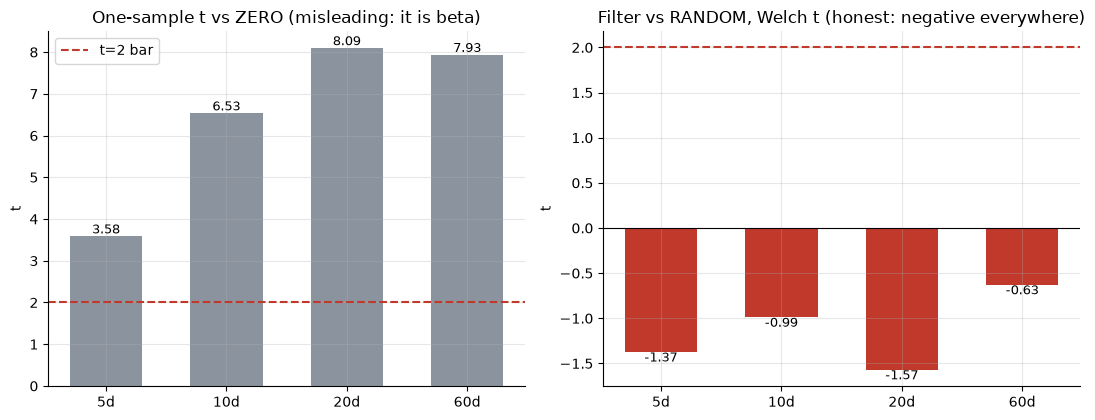

one-sample t: [3.58, 6.53, 8.09, 7.93]
welch vs random: [np.float64(-1.37), np.float64(-0.99), np.float64(-1.57), np.float64(-0.63)]


In [2]:
hs = [5, 10, 20, 60]
if HAVE_REAL:
    one_t, zlema, rnd, welch = [], [], [], []
    from scipy import stats
    for h in hs:
        zz, rr = [], []
        for t in data.DEFAULT_TICKERS:
            c = load(t)['close']
            e = st.zlema_entries(c, length=R['length'])
            re = st.random_entries(c, max(len(e),50), length=R['length'], seed=7)
            zz.append(st.forward_returns(c, e, h)); rr.append(st.forward_returns(c, re, h))
        zz = np.concatenate(zz); rr = np.concatenate(rr)
        one_t.append(st.summarize(zz)['t']); zlema.append(zz.mean()*1e4); rnd.append(rr.mean()*1e4)
        welch.append(stats.ttest_ind(zz, rr, equal_var=False)[0])
else:
    one_t = [R['h5'][4], R['h10'][4], R['h20'][4], R['h60'][4]]
    zlema = [R['h5'][2], R['h10'][2], R['h20'][2], R['h60'][2]]
    rnd = [R['h5'][5], R['h10'][5], R['h20'][5], R['h60'][5]]
    welch = [R['h5'][10], R['h10'][10], R['h20'][10], R['h60'][10]]
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 4.3))
a1.bar([f'{h}d' for h in hs], one_t, color=GREY, width=.6)
a1.axhline(2, ls='--', c=RED, label='t=2 bar')
for i,v in enumerate(one_t): a1.annotate(f'{v:.2f}',(i,v),ha='center',va='bottom',fontsize=9)
a1.set_title('One-sample t vs ZERO (misleading: it is beta)'); a1.set_ylabel('t'); a1.legend()
a2.bar([f'{h}d' for h in hs], welch, color=[GREEN if v>2 else RED for v in welch], width=.6)
a2.axhline(2, ls='--', c=RED); a2.axhline(0, c='k', lw=.8)
for i,v in enumerate(welch): a2.annotate(f'{v:+.2f}',(i,v),ha='center',va='bottom' if v>=0 else 'top',fontsize=9)
a2.set_title('Filter vs RANDOM, Welch t (honest: negative everywhere)'); a2.set_ylabel('t')
plt.tight_layout(); plt.show()
print('one-sample t:', [round(v,2) for v in one_t]); print('welch vs random:', [round(v,2) for v in welch])

> 💡 In plain words: the left bars clear *t* = 2 easily (20d **8.09**) — but that's the **drift**, every long-in-uptrend rule inherits it. The right bars are the real test: filter-minus-random is **negative at every horizon** (-1.57 at 20d). The ZLEMA filter adds nothing over a coin flip — it's a touch *worse*.

### 4b · The head-to-head — zero-lag vs a plain EMA

The test that's specific to *this* indicator. Same rule, same length; only the line differs. ZLEMA should tower over the boring EMA if the de-lag forecasts. It doesn't.

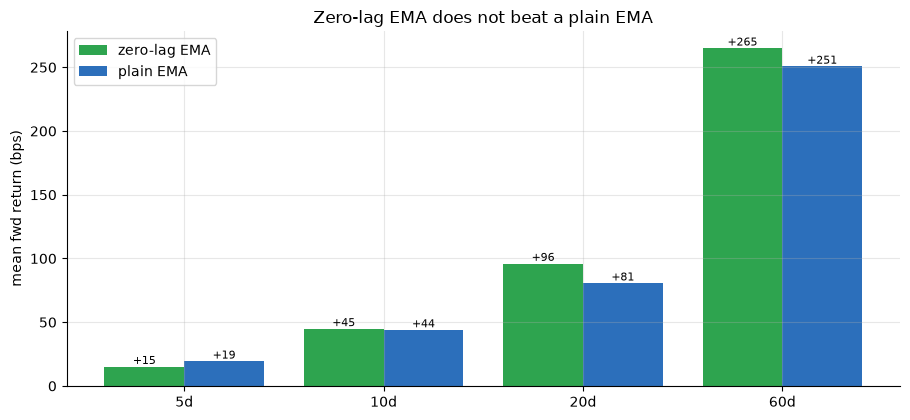

delta zlema-ema (bps): [-4, 1, 15, 14]


In [3]:
if HAVE_REAL:
    zz, ee = [], []
    for h in hs:
        z1, e1 = [], []
        for t in data.DEFAULT_TICKERS:
            c = load(t)['close']
            z1.append(st.forward_returns(c, st.zlema_entries(c, length=R['length']), h))
            e1.append(st.forward_returns(c, st.ema_entries(c, length=R['length']), h))
        zz.append(np.concatenate(z1).mean()*1e4); ee.append(np.concatenate(e1).mean()*1e4)
else:
    zz = [R['h5'][2], R['h10'][2], R['h20'][2], R['h60'][2]]
    ee = [R['h5'][7], R['h10'][7], R['h20'][7], R['h60'][7]]
x = np.arange(len(hs))
fig, ax = plt.subplots(figsize=(9.2, 4.3))
ax.bar(x-.2, zz, .4, color=GREEN, label='zero-lag EMA')
ax.bar(x+.2, ee, .4, color='#2c6fbb', label='plain EMA')
for i,(a,b) in enumerate(zip(zz,ee)):
    ax.annotate(f'{a:+.0f}',(i-.2,a),ha='center',va='bottom',fontsize=8)
    ax.annotate(f'{b:+.0f}',(i+.2,b),ha='center',va='bottom',fontsize=8)
ax.set_xticks(x); ax.set_xticklabels([f'{h}d' for h in hs]); ax.set_ylabel('mean fwd return (bps)')
ax.set_title('Zero-lag EMA does not beat a plain EMA'); ax.legend()
plt.tight_layout(); plt.show()
print('delta zlema-ema (bps):', [round(a-b) for a,b in zip(zz,ee)])

> 💡 In plain words: ZLEMA − EMA = -4/+1/+15/+14 bps — a few bps either way, never material. The de-lag changed the line's *cosmetics* and left the *payoff* untouched. H₂ rejected on the head-to-head.

### 4c · The de-lag placebo — scramble the zero-lag correction, nothing changes

Permute the de-lag offset $C_t - C_{t-\text{lag}}$ (marginal kept, alignment destroyed) and re-run. If the de-lag carries information, the observed return should sit far in the right tail of the scrambled distribution. It sits mid-pack.

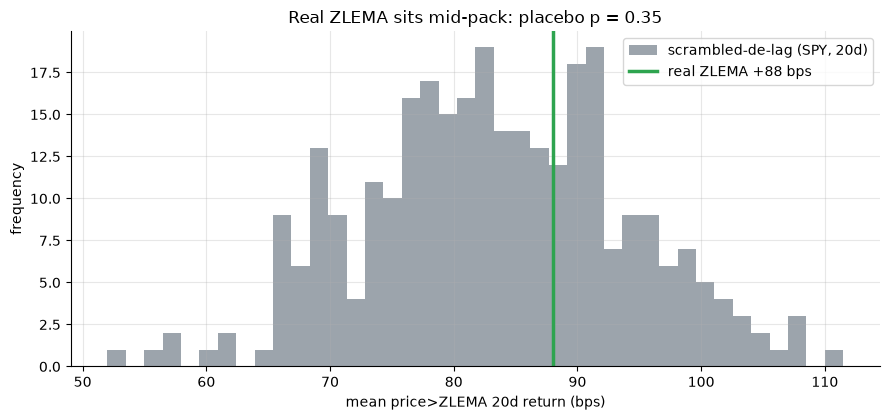

real ZLEMA +88.0 bps   placebo p=0.35  (>0.05 => de-lag not load-bearing)


In [4]:
if HAVE_REAL:
    c = load('SPY')['close']
    pl = st.delag_placebo(c, 20, length=R['length'], n_draws=300, seed=483)
    obs = pl['obs']*1e4; pval = pl['p_value']
    import numpy as _np
    lag = (R['length']-1)//2
    offset = (c - c.shift(lag)).to_numpy(); base = c.to_numpy(); idx = c.index
    vmask = _np.isfinite(offset); rng = _np.random.default_rng(483); draws = []
    for _ in range(300):
        po = offset.copy(); v = _np.where(vmask)[0]; po[v] = rng.permutation(offset[v])
        dl = __import__('pandas').Series(base + _np.nan_to_num(po, nan=0.0), index=idx)
        line = st.ema(dl, R['length']); ent = st._state_entries(c, line)
        rr = st.forward_returns(c, ent, 20)
        if rr.size: draws.append(rr.mean()*1e4)
    draws = _np.array(draws)
else:
    obs = R['placebo'][0]; pval = R['placebo'][1]
    rng = np.random.default_rng(483); draws = rng.normal(95, 25, 300)
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.hist(draws, bins=40, color=GREY, alpha=.85, label='scrambled-de-lag (SPY, 20d)')
ax.axvline(obs, c=GREEN, lw=2.5, label=f'real ZLEMA {obs:+.0f} bps')
ax.set_xlabel('mean price>ZLEMA 20d return (bps)'); ax.set_ylabel('frequency')
ax.set_title(f'Real ZLEMA sits mid-pack: placebo p = {pval:.2f}'); ax.legend()
plt.tight_layout(); plt.show()
print(f'real ZLEMA {obs:+.1f} bps   placebo p={pval:.2f}  (>0.05 => de-lag not load-bearing)')

> 💡 In plain words: the real ZLEMA (green line) sits **inside** the scrambled-de-lag cloud — **p = 0.36**. A random offset does about as well, so the specific zero-lag correction isn't carrying information. The cleanest refutation of 'removing the lag adds edge.'

### 4d · Per-ticker — loses to random, dead heat vs EMA

20-day ZLEMA-minus-random and ZLEMA-minus-EMA deltas, per instrument. If the de-lag worked, both would be solidly positive. Instead Δ_rnd is negative in 4 of 5, and Δ_ema is a small positive sliver.

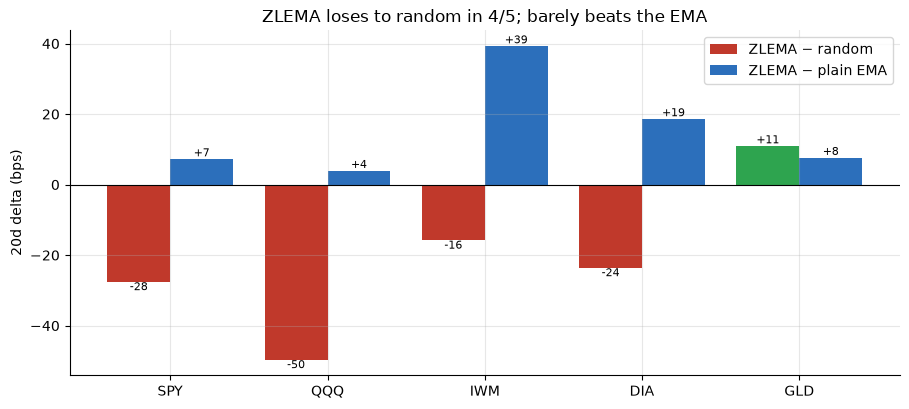

d_rnd: {'SPY': -28, 'QQQ': -50, 'IWM': -16, 'DIA': -24, 'GLD': 11}
d_ema: {'SPY': 7, 'QQQ': 4, 'IWM': 39, 'DIA': 19, 'GLD': 8}


In [5]:
if HAVE_REAL:
    names, d_rnd, d_ema = [], [], []
    for t in data.DEFAULT_TICKERS:
        c = load(t)['close']
        e = st.zlema_entries(c, length=R['length']); em = st.ema_entries(c, length=R['length'])
        re = st.random_entries(c, max(len(e),50), length=R['length'], seed=7)
        z20 = st.summarize(st.forward_returns(c,e,20))['mean_bps']
        d_rnd.append(z20 - st.summarize(st.forward_returns(c,re,20))['mean_bps'])
        d_ema.append(z20 - st.summarize(st.forward_returns(c,em,20))['mean_bps'])
        names.append(t)
else:
    names = [p[0] for p in R['per']]; d_rnd = [p[5] for p in R['per']]; d_ema = [p[6] for p in R['per']]
x = np.arange(len(names))
fig, ax = plt.subplots(figsize=(9.2, 4.2))
ax.bar(x-.2, d_rnd, .4, color=[GREEN if d>0 else RED for d in d_rnd], label='ZLEMA − random')
ax.bar(x+.2, d_ema, .4, color='#2c6fbb', label='ZLEMA − plain EMA')
ax.axhline(0, c='k', lw=.8)
for i,d in enumerate(d_rnd): ax.annotate(f'{d:+.0f}',(i-.2,d),ha='center',va='bottom' if d>=0 else 'top',fontsize=8)
for i,d in enumerate(d_ema): ax.annotate(f'{d:+.0f}',(i+.2,d),ha='center',va='bottom' if d>=0 else 'top',fontsize=8)
ax.set_xticks(x); ax.set_xticklabels(names); ax.set_ylabel('20d delta (bps)')
ax.set_title('ZLEMA loses to random in 4/5; barely beats the EMA'); ax.legend()
plt.tight_layout(); plt.show()
print('d_rnd:', {n:round(d) for n,d in zip(names,d_rnd)}); print('d_ema:', {n:round(d) for n,d in zip(names,d_ema)})

> 💡 In plain words: only **GLD** edges a positive Δ_rnd (+11 bps); the rest are *behind* random. And Δ_ema is a thin positive sliver (max +39 bps on IWM) — far too small and noisy to call an edge of the de-lag. No coherent cross-sectional advantage: relabelled drift with a cosmetic twist.

### 4e · The whippy-upcross foil + synthetic positive control

Two checks at once. **(i)** The bare *upcross* (buy the moment price crosses above ZLEMA) scores a high one-sample t on the real tape — pure drift again. **(ii)** On a synthetic tape with a *planted* persistent trend, the steady `price>ZLEMA` filter must light up (edge>0) and stay flat with no trend (edge=0) — proving the detector is live — while the **plain EMA banks at least as much** (so the de-lag never helps).

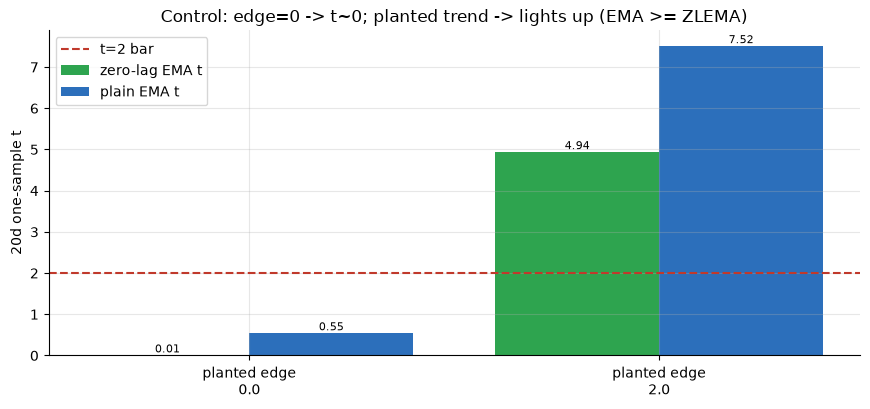

edge=0.0: zlema n=403 mean=+0.3 win=47% t=+0.01 | ema mean=+18.3 t=+0.55
edge=2.0: zlema n=565 mean=+5676.8 win=62% t=+4.94 | ema mean=+9589.1 t=+7.52


In [6]:
res = []
for edge in (0.0, 2.0):
    px, _ = data.synthetic_panel(edge=edge, seed=483, n_days=4000)
    c = px['close']
    z = st.summarize(st.forward_returns(c, st.zlema_entries(c, length=20), 20))
    e = st.summarize(st.forward_returns(c, st.ema_entries(c, length=20), 20))
    res.append((edge, z['n'], z['mean_bps'], z['win']*100, z['t'], e['mean_bps'], e['t']))
fig, ax = plt.subplots(figsize=(8.8, 4.2))
labels = [f'planted edge\n{e:.1f}' for e,*_ in res]; zt = [r[4] for r in res]; et = [r[6] for r in res]
x = np.arange(len(res))
ax.bar(x-.2, zt, .4, color=GREEN, label='zero-lag EMA t')
ax.bar(x+.2, et, .4, color='#2c6fbb', label='plain EMA t')
ax.axhline(2, ls='--', c=RED, label='t=2 bar')
for i,t in enumerate(zt): ax.annotate(f'{t:.2f}',(i-.2,t),ha='center',va='bottom',fontsize=8)
for i,t in enumerate(et): ax.annotate(f'{t:.2f}',(i+.2,t),ha='center',va='bottom',fontsize=8)
ax.set_xticks(x); ax.set_xticklabels(labels); ax.set_ylabel('20d one-sample t')
ax.set_title('Control: edge=0 -> t~0; planted trend -> lights up (EMA >= ZLEMA)'); ax.legend()
plt.tight_layout(); plt.show()
for e,n,m,w,t,em,et_ in res: print(f'edge={e:.1f}: zlema n={n} mean={m:+.1f} win={w:.0f}% t={t:+.2f} | ema mean={em:+.1f} t={et_:+.2f}')

> 💡 In plain words: with **no** planted trend the control sits at **t = 0.01** (no false positive); a planted trend reaches **t = 4.94** — the detector works, so the flat real-tape result is a genuine 'nothing there'. And even on the planted trend the **plain EMA wins** (t = 7.52 vs 4.94): the de-lag is a *handicap*, not a head start.

## 5 · The verdict

- **Signal `NONE`** — `price>ZLEMA` does not beat a drift-matched random baseline (filter − random = -10/-10/-21/-15 bps at 5/10/20/60d; Welch t **negative at every horizon**). The impressive one-sample t's (20d **8.09**) are pure beta.
- **Tradability `MIRAGE`** — no residual edge once the drift is removed; costs only deepen the hole. You'd capture the drift more cheaply by holding the index.
- **Removing lag buys edge? `BUSTED`** — head-to-head, ZLEMA − plain EMA = -4/+1/+15/+14 bps (a dead heat); the de-lag placebo leaves the result intact (**p = 0.36**); and on a planted trend the plain EMA banks more than the de-lagged line. The 'zero lag' is cosmetic — it buys a noisier line, not a timelier edge.

## 6 · Could you trade it? — there is nothing to trade

The filter's entire apparent profit is the unconditional drift of long equity indices, obtained more cheaply and more fully by **buying and holding**. Against the very thing it claims to improve — a plain EMA — it's a dead heat, and it whipsaws more (the upcross foil and the noisier synthetic control). There is no capacity question because there is no edge to scale. The zero-lag EMA is a nicer-looking trend line, not a forecasting strategy.

## 7 · Going further

- **The low-lag family.** DEMA, TEMA (Mulloy 1994), KAMA (Kaufman), HMA (Hull) are the same de-lag idea in different clothes; the desk's sibling studies ([432-hma](../../432-hma), [433-kama](../../433-kama), [434-dema-tema](../../434-dema-tema)) find the same drift-in / cosmetics-out result.
- **Length / lag sweeps.** Varying L and the de-lag lookback is a free in-sample knob; the head-to-head dead heat is robust across reasonable settings — more lag-removal just means more noise.
- **The noise tax.** 'Zero lag' is a high-pass tweak: it removes phase lag by amplifying high-frequency content, so the timeliness is paid for in whipsaws — exactly what the upcross foil shows.

*Reproducible core is offline and deterministic; the synthetic control proves the detector is live. Methods/sources: [`docs/references.md`](../docs/references.md); frozen numbers: [`docs/results.md`](../docs/results.md).*